## This workbook runs an updated version of the `dorado` particle tracking model with `ANUGA` hydrodynamic outputs. 

The main changes made to `dorado` for this research were adding optional variables to be tracked with the particles, including a user-defined roi grid for particle flagging. The roi grid used in this study is based on the friction map used to develop the hydrodynamic outputs, which was based on vegetation. 

We are flagging particles here to recognize regions where enhanced nutrient processing could occur. 

The full `ANUGA` results are stored here, but our simulations ran on a subset of those results, which are uploaded with the manuscript.
Wright, K. A., & Passalacqua, P. (2024). Delta-X: Calibrated ANUGA Hydrodynamic Outputs for the Atchafalaya Basin, MRD, LA (Version 1). ORNL Distributed Active Archive Center. https://doi.org/10.3334/ORNLDAAC/2306 Date Accessed: 2026-03-26

### NOTE: Every time `dorado` is run, the user is subject to slightly different results because of the random-walk involved in particle tracking. The model results used for the manuscript are uploaded in the results folder. Any re-running of `dorado` would present a slightly different suite of particle paths.

Any user would need to explicitly clone the `dorado` repo that is currently found on Eleanor Henson's GitHub (https://github.com/eghenson/dorado), which will hopefully be merged with parent `dorado` repository soon.

Required files to run:
- "../input_data/dorado_inputs/WLAD_Boundary.csv"
- "../input_data/dorado_inputs/Friction_ROI.tif
- The 9 ANUGA .nc files correspondning to the last 9/14 days in the Wright et al. 2024 models. 
    - These files are too big for GitHub and will have to be downloaded separately from the link above by the user.
    - We suggest saving them in "../dorado_inputs/FC" and "../dorado_inputs/SC" for consistency with this notebook.

In [1]:
import numpy as np
import scipy
import matplotlib
import pandas as pd
from matplotlib import pyplot as plt
import json
import sys
import os
import xarray
import math
from matplotlib.path import Path
import rasterio
import pickle
import gzip

# Define the path to the cloned dorado - this is just where mine lived 
dorado_repo = os.path.abspath(os.path.join("../../", "dorado"))

# Add the path to sys.path if it's not already there
if dorado_repo not in sys.path:
    sys.path.append(dorado_repo)

# Import the desired modules
from dorado import particle_track as pt
from dorado import routines as drt

In [2]:
# --------------------------------------------------------------------------
# Initial model inputs - important to assign season here and change file paths
# --------------------------------------------------------------------------
scenario = 'SC' # FC or SC for fall or spring campiagns, respectively
base_dir = "../" # User should adjust this to a working directory 
hydro_results_path = f"{base_dir}/input_data/dorado_inputs/{scenario}" # User should adjust this to the hydrodynamic outputs, either to a folder with the fall or spring data
inputs_path = f"{base_dir}/input_data/dorado_inputs"

In [3]:
# --------------------------------------------------------------------------
# Load ANUGA model outputs for first day to acquire interp function--- 
# this will make it run faster while looping through files
# --------------------------------------------------------------------------
grid_size = 25 # meters - does not change, based on hydro outputs
particle_counts = [24000] # User can adjust this to a list to run multiple simulations, or keep as is

# Pull the first file to run interp function
if scenario == 'SC':
    file = 'Hydro_WLAD_20210325_DXS.nc'
else:
    file = '.\\Hydro_WLAD_20210819_DXF.nc'

swwvals = xarray.load_dataset(os.path.join(hydro_results_path,file))
print("Variable names and types in swwvals dataset:")
for var_name in swwvals.data_vars:
    var_type = swwvals[var_name].dtype
    print(f"{var_name}: {var_type}")
    
# Extract coordinates and mesh data of UTM grid
x = swwvals['x'].data
y = swwvals['y'].data
time = swwvals['time'].data
mesh = swwvals['mesh'].data
topo = swwvals['topo'].data

# Transform coordinates to dorado grid
x_centroids = ( x[mesh[0,:]] + x[mesh[1,:]] + x[mesh[2,:]] ) / 3 # mesh is the indices 
y_centroids = ( y[mesh[0,:]] + y[mesh[1,:]] + y[mesh[2,:]] ) / 3
coordinates = [(x_centroids[i], y_centroids[i]) for i in list(range(len(x_centroids)))]
num_coords = len(coordinates)
print('number of coordinates prior to crop:', num_coords)

# Crop region
WLAD_coord = [[639000., 3278800.],[671900., 3278800.],
              [671900., 3245000.],[639000., 3245000.]]

# Use matplotlib's Path to find cells inside polygon
path = Path(WLAD_coord)
inside = path.contains_points(coordinates)
x = x_centroids[inside]
y = y_centroids[inside]
coordinates = [(x[i], y[i]) for i in list(range(len(x)))]
num_coords_in = len(coordinates)
print('number of coordinates post crop:',num_coords_in)

# Let's see the extent of our domain, to make sure-- these are the centroid coordinates within our crop box
# The grid is based on the centroids within the region
print('domain extent:' , min(x), max(x), min(y), max(y))

# Underscore indicates unstructured variables to be gridded
_bathy = topo[inside] 

# Use IDW interpolation interpolate unstructured data into uniform grid
bounds = np.loadtxt(f'{inputs_path}/WLAD_Boundary.csv', delimiter=',')
myInterp, bathy = pt.unstruct2grid(coordinates, _bathy, grid_size, 3, bounds) # This is the interpolation function used later
print('Bathy shape:', bathy.shape)

# Save the bathy as a .npy file -- bathy does not change between models though, just friction
# np.save('bathy' + scenario + '.npy', bathy)

Variable names and types in swwvals dataset:
xvel: float32
yvel: float32
xmom: float32
ymom: float32
depth: float32
stage: float32
topo: float32
fric_class: int64
mannings_n: float64
baptist_m: int64
baptist_D: float64
baptist_h: float64
mesh: int32
number of coordinates prior to crop: 1544332
number of coordinates post crop: 1146739
domain extent: 639004.375 671899.9791666666 3245000.1666666665 3278800.0
Bathy shape: (1353, 1317)


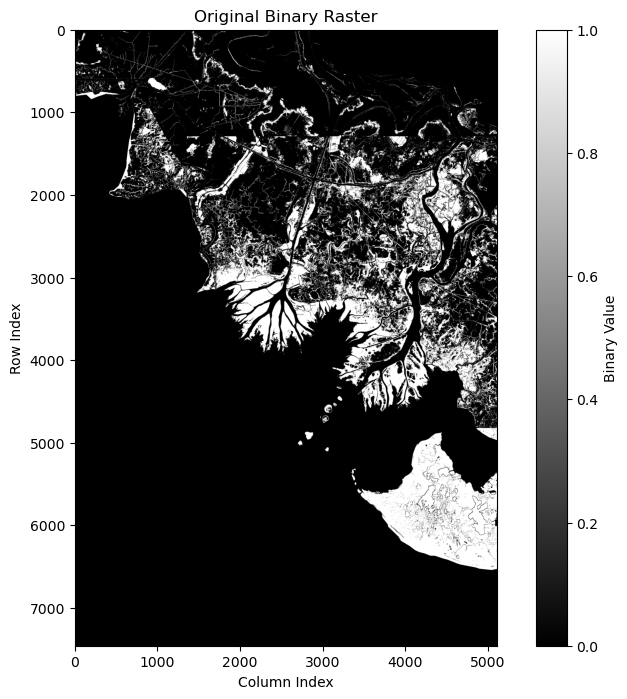

ROI grid saved to ..//input_data/dorado_inputs/ROI_grid.npy
ROI_grid shape: (1353, 1317)


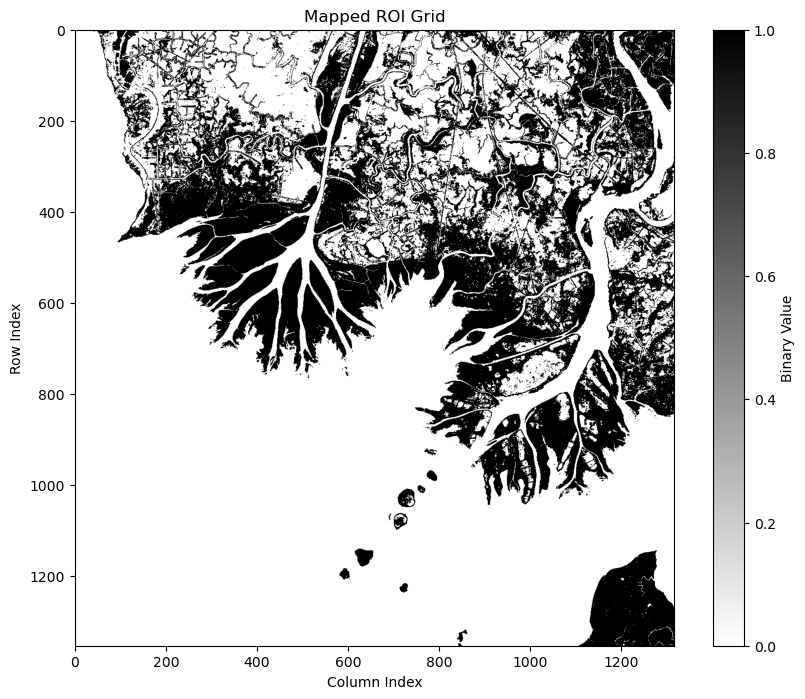

In [4]:
# --------------------------------------------------------------------------
# Convert ROI grid (for flagging) to the same orientation and shape as dorado model
# --------------------------------------------------------------------------
tif_path = os.path.join(inputs_path, "Friction_ROI.tif")

def make_gridded_ROI_from_shapefile(tif_path, x_coords, y_coords, grid_size, output_npy='ROI_grid.npy', plot=True):
    """
    Convert a binary raster TIFF to a model-aligned ROI grid using model-derived x and y extent. 
    
    Please note this function flips the y-axis to match the model grid orientation from raster coordinates.

    Parameters
    ----------
    tif_path : str
        Path to the binary raster (.tif).
    x_coords : array-like
        X-coordinates from the model domain (e.g., centroids from ANUGA hydrodynamic model results).
    y_coords : array-like
        Y-coordinates from the model domain.
    grid_size : float
        Grid cell size used in the model.
    output_npy : str
        Path to save the output ROI grid as a .npy file.
    plot : bool
        Whether to plot the input and output rasters.

    Returns
    -------
    ROI_grid : np.ndarray
        The gridded region of interest (same shape as the model domain grid).
    """

    # ----------------------------------------------------------------------
    # Load Binary Raster
    # ----------------------------------------------------------------------
    with rasterio.open(tif_path) as src:
        transform = src.transform
        binary_raster = src.read(1)

    if plot:
        plt.figure(figsize=(10, 8))
        plt.imshow(binary_raster, cmap='gray', origin='upper')
        plt.colorbar(label='Binary Value')
        plt.title('Original Binary Raster')
        plt.xlabel('Column Index')
        plt.ylabel('Row Index')
        plt.show()

    # ----------------------------------------------------------------------
    # Define Target Grid from Model Extents
    # ----------------------------------------------------------------------
    cellsize = float(grid_size)
    x_min, y_min = min(x_coords), min(y_coords)
    x_max, y_max = max(x_coords), max(y_coords)
    nx = int(np.ceil((x_max - x_min) / cellsize) + 1)
    ny = int(np.ceil((y_max - y_min) / cellsize) + 1)

    ROI_grid = np.zeros((ny, nx), dtype=int)

    # ----------------------------------------------------------------------
    # Map Raster to Model Grid
    # ----------------------------------------------------------------------
    rows, cols = np.where(binary_raster == 1)
    x_geo = transform[2] + cols * transform[0]
    y_geo = transform[5] + rows * transform[4]

    grid_x_idx = ((x_geo - x_min) / cellsize).astype(int)
    grid_y_idx = ((y_geo - y_min) / cellsize).astype(int)
    grid_y_idx_flipped = (ny - 1) - grid_y_idx

    valid = (
        (0 <= grid_x_idx) & (grid_x_idx < nx) &
        (0 <= grid_y_idx_flipped) & (grid_y_idx_flipped < ny)
    )

    ROI_grid[grid_y_idx_flipped[valid], grid_x_idx[valid]] = 1

    np.save(output_npy, ROI_grid)
    print(f"ROI grid saved to {output_npy}")
    print(f"ROI_grid shape: {ROI_grid.shape}")

    if plot:
        plt.figure(figsize=(10, 8))
        plt.imshow(ROI_grid, cmap='binary')
        plt.colorbar(label='Binary Value')
        plt.title('Mapped ROI Grid')
        plt.xlabel('Column Index')
        plt.ylabel('Row Index')
        plt.show()

    return ROI_grid

roi_grid = make_gridded_ROI_from_shapefile(
    tif_path = tif_path,
    x_coords=x,
    y_coords=y,
    grid_size=25,
    output_npy=f'{inputs_path}/ROI_grid.npy',
    plot=True
)

(723.0, 23.0)

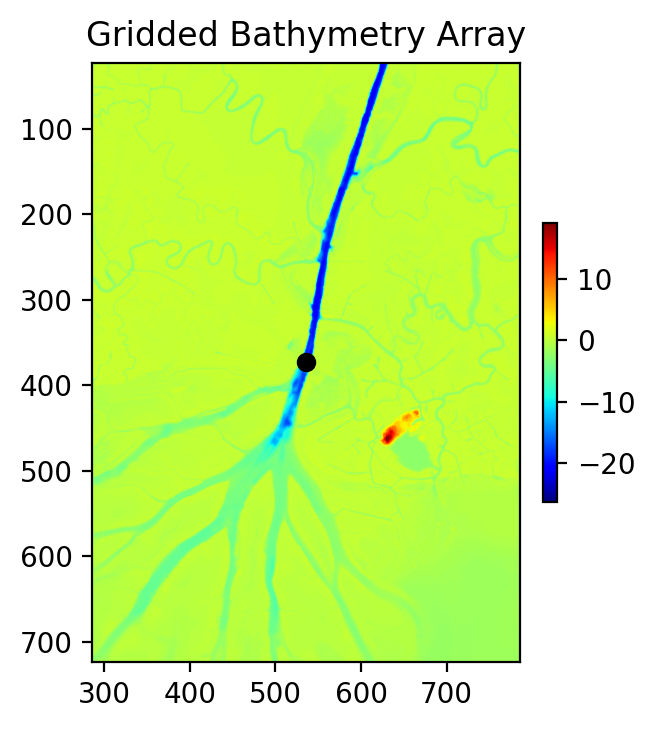

In [5]:
# -------------------------------------------------------------
# Define and visualize particle seeding location
# -------------------------------------------------------------
seedloc = [(652396, 3269506)] # Coordinates in UTM
# Call the coordinate transform function
seedind = pt.coord2ind(seedloc, (min(x), min(y)), 
                         np.shape(bathy), 25.0)

# # Visualize the location on our array
plt.figure(figsize=(3,5), dpi=200)
plt.scatter(seedind[0][1], seedind[0][0], c='k')
plt.imshow(bathy, cmap='jet')
plt.colorbar(fraction=0.03)
plt.title('Gridded Bathymetry Array')
plt.xlim([seedind[0][1]-250, seedind[0][1]+250])
plt.ylim([seedind[0][0]+350, seedind[0][0]-350])

In [6]:
# --------------------------------------------------------------------------
# Initialize Particle Injection
# These parameters were not changed until the sensitivity runs for diff_coeff
# --------------------------------------------------------------------------
# Start populating particle model with settings
params = pt.modelParams()

# Constant Particle Parameters
params.dx = grid_size
params.model = 'Anuga'
params.topography = bathy
params.roi_grid = roi_grid
params.theta = 1.0 # for nutrients or soluble materials
params.gamma = 0.05 # ==1 means random walk weights are independent of discharge, and are only based on WSE graduients 
params.dry_depth = 0.01 # 1 cm dry depth
params.verbose = False
params.diff_coeff = 0.2
params.particle_variables = ['depth'] # additional variable to save

#diff_coeff_values = [0.1, 0.2, 0.4, 0.6]
# diff_coeff = [0.2]  for standard run
# Max diffusion time at any given step is 0.5*diff_coeff percent. 
# Default is 0.2- max of 10% diffusion per step

# Timestep inputs
num_seed_steps = 2*24 # 2 batches per hour for first day
num_days = 9 # should be 9 for full run, but just doing 1 day for testing
num_total_steps = (2*24*num_days) # the last day has one less timestep (Unique to our hydrodynamic outputs)
num_daily_steps = 2*24 # every half hour 
# Create vector of target times
target_times = np.arange(1800, 1800*(num_total_steps+1), 1800)


# Discharge inputs for seeding - has both spring and fall
Q = pd.read_csv(f"{inputs_path}/Particle_Q.csv").to_numpy() 

In [ ]:
# --------------------------------------------------------------------------
# Run dorado with particle counts
# --------------------------------------------------------------------------
path2anuga = hydro_results_path

for num_particles in particle_counts:
    print("\n" + "="*60)
    print(f"RUNNING DORADO WITH {num_particles} PARTICLES")
    print("="*60)
    outfolder = f"{base_dir}/results/dorado_results/{scenario}_baseline/"
    if not os.path.exists(outfolder):
        os.makedirs(outfolder)
        print(f"Created directory: {outfolder}")
    
    # --------------------------------------------------------------------------
    # Flux-proportional particle seeding (FIRST DAY ONLY)
    # --------------------------------------------------------------------------
    if scenario == "SC":
        Q_sc = Q[:, 1]   # second column
        Np_per_step_array = pt.flux_proportional_seeding(
            Q=Q_sc,
            N_total=num_particles,
            num_steps=num_seed_steps
        )
        np.save(os.path.join(outfolder, f"particles_per_timestep_{scenario}.npy"), Np_per_step_array)

    else:
        Q_fc = Q[:, 2]   # third column
        Np_per_step_array = pt.flux_proportional_seeding(
            Q=Q_fc,
            N_total=num_particles,
            num_steps=num_seed_steps
        )
        np.save(os.path.join(outfolder, f"particles_per_timestep_{scenario}.npy"), Np_per_step_array)

    # --------------------------------------------------------------------------
    # INITIALIZE DORADO TIME LOOP AND RUN FOR THE 9 DAYS OF EACH SEASON
    # --------------------------------------------------------------------------
    day_index = 0
    walk_data = None
    global_step = 0 

    # Loop through the hydrodynamic files for each day, and then loop through the timesteps within each day
    for day_index, filename in enumerate(sorted(os.listdir(path2anuga))[:num_days]):
        # ----------------------------------------------------------------------
        # Load hydrodynamic file
        # ----------------------------------------------------------------------
        swwvals = xarray.load_dataset(os.path.join(path2anuga, filename))
        if day_index == 8:
            num_daily_steps = num_daily_steps - 1 # last day only has one less timestep
        else:
            num_daily_steps = num_daily_steps

        depth = swwvals['depth']
        stage = swwvals['stage']
        xmom = swwvals['xmom']
        ymom = swwvals['ymom']

        _depth  = np.zeros((num_daily_steps, sum(inside)))
        _stage  = np.ones_like(_depth) * np.nan
        _qx     = np.zeros_like(_depth)
        _qy     = np.zeros_like(_depth)
        
        for ii in range(num_daily_steps):
            _depth[ii,:] = depth[ii,inside]
            _stage[ii,:] = stage[ii,inside]
            _qx[ii,:] = xmom[ii,inside]
            _qy[ii,:] = ymom[ii,inside]
        del swwvals
        print(f"Loaded hydrodynamics for day {day_index}: {filename}")
        
        # ---------------------------------------------------------------------
        # Time loop for particle tracking over the day
        # ---------------------------------------------------------------------
        for i in list(range(num_daily_steps)):
            t_eff = i
            # Update flow fields
            params.depth = myInterp(_depth[t_eff,:])
            params.stage = myInterp(_stage[t_eff,:])
            params.qx = myInterp(_qx[t_eff,:])
            params.qy = myInterp(_qy[t_eff,:])
            # Define the particle class and continue
            particle = pt.Particles(params)

            # Check if we're still in seeding window (first day)
            if day_index == 0:
                # Generate new batch of particles
                np_step = int(Np_per_step_array[i])
                particle.generate_particles(np_step, [seedind[0][0]], [seedind[0][1]], i*1800,
                                                'random', walk_data)
                # >>> SEEDING PRINT STATEMENT <<<
                print(f"[SEEDING] Day {day_index}, "f"timestep {i:02d}, "f"time = {i*0.5:.1f} hr, "f"particles = {np_step}")
                if np_step == 0:
                    print(f"  ⚠️  No particles seeded at timestep {i} (low or zero discharge)")
            else:
                particle.generate_particles(0, [], [], previous_walk_data=walk_data)
        
            # Run the random walk for this "model timestep" 
            walk_data = particle.run_iteration(target_times[global_step]) # this is the timestep value pulled in seconds 
            global_step += 1

            # Use get_state() to return original and most recent locations
            x0, y0, t0, optional_data0 = drt.get_state(walk_data, 0) # Starting locations
            xi, yi, ti, optional_data = drt.get_state(walk_data) # Most recent locations
            
            # Convert to NumPy array
            xi = np.array(xi)
            yi = np.array(yi)
            fi = np.array(optional_data['roi_flag'])
            
            # ---------------------------------------------------------------------
            # PLOTTING SECTION (this code plots every 3 hours)
            # ---------------------------------------------------------------------
            # Separate the two groups for plotting - flagged and not flagged particles
            mask_fi0 = fi == 0
            mask_fi1 = fi == 1   
            
            if day_index in range(0,10) and i % 6 ==0:
                # Make and save plots and data
                fig = plt.figure(dpi=200)
                ax = fig.add_subplot(111)            
                # Plot initial locations
                ax.scatter(y0, x0, c='b', s=0.75)
                # Plot particles in blue (fi = 0)
                ax.scatter(yi, xi, c='blue', s=0.75, label='fi = 0')
                # Plot particles in blue (fi = 0)
                ax.scatter(yi[mask_fi0], xi[mask_fi0], c='blue', s=0.75, label='fi = 0')
                # Plot particles in red (fi = 1, in ROI)
                ax.scatter(yi[mask_fi1], xi[mask_fi1], c='red', s=0.25, label='fi = 1')
                ax = plt.gca()
                # Set axis limits
                ax.set_xlim([200,700])  # x-axis limits
                ax.set_ylim([825, 250])  # y-axis limits
                # Overlay depth plot
                im = ax.imshow(params.depth, cmap='viridis')
                plt.title(f'Day {day_index} Hour {(i+1)*1800/3600:.1f}') # Convert timestep to hours
                # Colorbar
                cax = fig.add_axes([
                    ax.get_position().x1 + 0.01, 
                    ax.get_position().y0, 
                    0.02, 
                    ax.get_position().height])
                cbar = plt.colorbar(im, cax=cax)
                cbar.set_label('Water Depth [m]')
                # Plot ROI_grid with transparency
                #ax.imshow(roi_grid, cmap='binary', origin='upper', alpha=0.25)
                # Save figure
                plt.savefig(f"{outfolder}/day_{day_index}_hour_{i*1800//3600}.png")
                plt.close(fig)
                print(f'Particles routed to hour {i*1800//3600}')
        day_index += 1

    # --------------------------------------------------------------------------
    # RUNTIME SANITY CHECK (end of this particle-count run)
    # --------------------------------------------------------------------------
    if walk_data is None:
        raise RuntimeError("walk_data is None — Dorado did not generate particles.")

    # Number of particles actually simulated
    n_particles_simulated = len(walk_data['xinds'])

    print("\n" + "-"*60)
    print(f"Completed Dorado run with {num_particles} seeded particles")
    print(f"Total particles currently tracked: {n_particles_simulated}")
    print("-"*60 + "\n")

    if n_particles_simulated == 0:
        raise RuntimeError("No particles were tracked — check seeding logic.")
    
    # SAVE WALK DATA 
    with gzip.open(outfolder + '/'+  scenario + '_wd.pkl',"wb") as f:
        pickle.dump(walk_data, f)


RUNNING DORADO WITH 24000 PARTICLES
Created directory: ..//results/dorado_results/SC_baseline/
Loaded hydrodynamics for day 0: Hydro_WLAD_20210325_DXS.nc


C:\Users\ehenson\AppData\Local\Temp\ipykernel_25440\2250442461.py:83: DeprecationWarning: The 'verbose' parameter is deprecated. Use dorado.setup_logging() instead.
  particle = pt.Particles(params)


[SEEDING] Day 0, timestep 00, time = 0.0 hr, particles = 464
Particles routed to hour 0
[SEEDING] Day 0, timestep 01, time = 0.5 hr, particles = 478
[SEEDING] Day 0, timestep 02, time = 1.0 hr, particles = 489


KeyboardInterrupt: 